<a href="https://colab.research.google.com/github/Chait314/special_proj_314/blob/main/SP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Setup

Inputs:
l/h → plate length ratio
d/h → submergence depth ratio

Output:
P_ext → extracted power

Observed behaviour:
Quadratic relation with l/h
linear relation with d/h
max around l/h=2.8
lower d/h higher power



In [ ]:
import numpy as np;
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import torch;
import torch.nn as nn;
from torch.utils.data import DataLoader, TensorDataset;
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42);

In [ ]:
l_h = np.random.uniform(0,5,400);
d_h = np.random.uniform(0.0, 0.4, 400);


In [ ]:
P_ext = (
    900*np.exp(-((l_h - 2.8) ** 2) / 0.5)
    - 150*d_h
    + np.random.normal(0, 20, 400)
)

X = np.column_stack((l_h, d_h))
y = P_ext

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

In [ ]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__();
        self.model = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.model(x);

In [ ]:
ann = ANN();

In [ ]:
import torch.optim as optim;
optimizer = optim.AdamW(ann.parameters(), lr=0.001);

In [ ]:
score = [];
criterion = nn.MSELoss(); # Define a loss function
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True);
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)
for a in range(1000):
  ann.train();
  for batch_index, (inputs, labels) in enumerate(train_loader):
      outputs = ann(inputs);
      loss = criterion(outputs.squeeze(), labels);
      optimizer.zero_grad();
      loss.backward();
      optimizer.step();
      score.append(loss.item());

  ann.eval();
  all_preds = [];
  all_labels = [];
  running_val_loss = 0.0;
  vals = [];

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = ann(inputs);
      loss = criterion(outputs.squeeze(), labels);
      running_val_loss += loss.item();
      all_preds.extend(outputs.squeeze().tolist());
      all_labels.extend(labels.tolist());
      vals.append(loss.item())

In [ ]:
y_pred = ann(X_val)
ann.eval();
r2 = r2_score(y_val.detach().numpy(), y_pred.squeeze().detach().numpy())
mae = mean_absolute_error(y_val.detach().numpy(), y_pred.squeeze().detach().numpy())

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: -0.3681964874267578
MAE: 217.93319702148438


In [ ]:
l_opt = torch.rand(3000) * 5
d_opt = torch.rand(3000) * 0.4

X_opt = torch.stack((l_opt, d_opt), dim=1)

ann.eval()
with torch.no_grad():
    power_pred = ann(X_opt).squeeze()

top5 = torch.topk(power_pred, 5);

for idx in top5.indices:
    print("l/h:", l_opt[idx].item(),
          "d/h:", d_opt[idx].item(),
          "Power:", power_pred[idx].item())

print(power_pred);

l/h: 2.687565803527832 d/h: 0.37329015135765076 Power: 0.0
l/h: 4.52232027053833 d/h: 0.10144772380590439 Power: 0.0
l/h: 4.291021347045898 d/h: 0.2344583123922348 Power: 0.0
l/h: 2.6537587642669678 d/h: 0.24909888207912445 Power: 0.0
l/h: 2.576578140258789 d/h: 0.13972723484039307 Power: 0.0
tensor([0., 0., 0.,  ..., 0., 0., 0.])


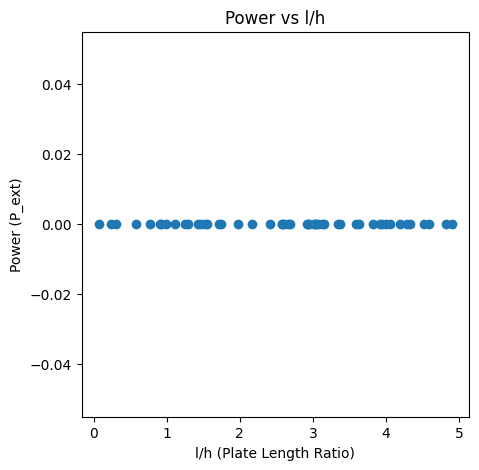

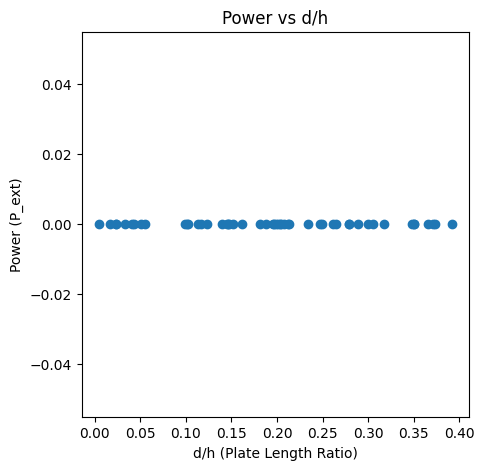

In [ ]:
plt.figure(figsize=(5,5));
plt.scatter(l_opt[:50], power_pred[:50])
plt.xlabel("l/h (Plate Length Ratio)")
plt.ylabel("Power (P_ext)")
plt.title("Power vs l/h")
plt.show()

plt.figure(figsize=(5,5));
plt.scatter(d_opt[:50], power_pred[:50])
plt.xlabel("d/h (Plate Length Ratio)")
plt.ylabel("Power (P_ext)")
plt.title("Power vs d/h")
plt.show();


Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score;

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42);
rf.fit(X_train, y_train);

y_pred = rf.predict(X_val);
print("R2: ", r2_score(y_val, y_pred));

R2:  0.9923528440497706


In [ ]:
l_rf_opt = np.random.uniform(0,5,3000);
d_rf_opt = np.random.uniform(0,0.4,3000);

X_rf_opt = np.column_stack((l_rf_opt, d_rf_opt));

power_pred_rf = rf.predict(X_rf_opt);

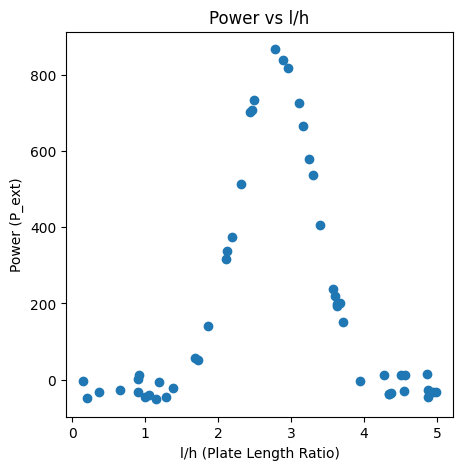

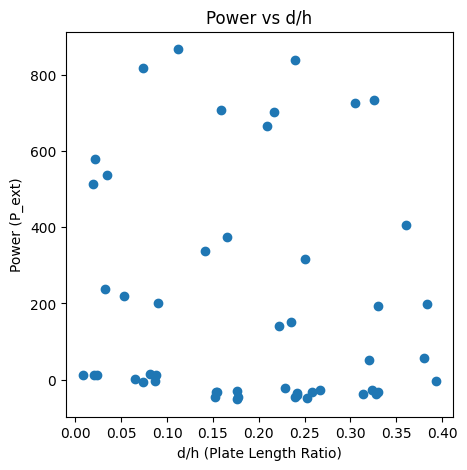

In [ ]:
plt.figure(figsize=(5,5));
plt.scatter(l_rf_opt[:50], power_pred_rf[:50])
plt.xlabel("l/h (Plate Length Ratio)")
plt.ylabel("Power (P_ext)")
plt.title("Power vs l/h")
plt.show()

plt.figure(figsize=(5,5));
plt.scatter(d_rf_opt[:50], power_pred_rf[:50])
plt.xlabel("d/h (Plate Length Ratio)")
plt.ylabel("Power (P_ext)")
plt.title("Power vs d/h")
plt.show();

XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score


xgb = XGBRegressor(
    n_estimators = 300,
    learning_rate = 0.1,
    max_depth = 3,
)

xgb.fit(X_train, y_train);
y_pred = xgb.predict(X_val);
print("R2: ", r2_score(y_val, y_pred));

R2:  0.9918702840805054


In [ ]:
l_xg_opt = np.random.uniform(0,5,3000);
d_xg_opt = np.random.uniform(0,0.4,3000);

X_xg_opt = np.column_stack((l_xg_opt, d_xg_opt));

power_pred_xg = xgb.predict(X_xg_opt);

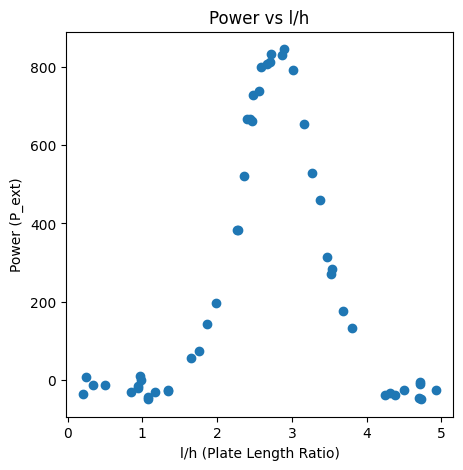

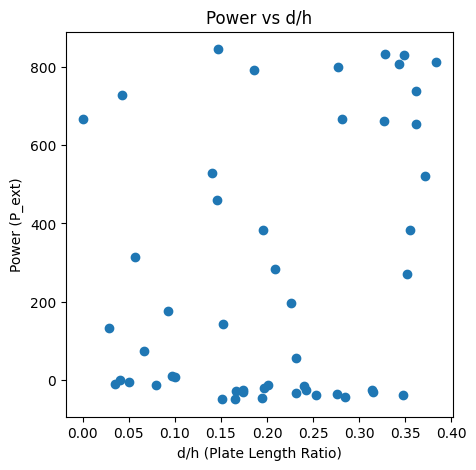

In [ ]:
plt.figure(figsize=(5,5));
plt.scatter(l_xg_opt[:50], power_pred_xg[:50])
plt.xlabel("l/h (Plate Length Ratio)")
plt.ylabel("Power (P_ext)")
plt.title("Power vs l/h")
plt.show()

plt.figure(figsize=(5,5));
plt.scatter(d_xg_opt[:50], power_pred_xg[:50])
plt.xlabel("d/h (Plate Length Ratio)")
plt.ylabel("Power (P_ext)")
plt.title("Power vs d/h")
plt.show();

Novel Idea

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel;

In [ ]:
kernel = C(1.0)*RBF(length_scale=[1.0, 0.1]) + WhiteKernel(noise_level=1)

In [ ]:
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=[1, 0.1]) + WhiteKernel(noise_level=1),
                         n_restarts_optimizer=10)

In [ ]:
y_pred, y_std = gp.predict(X_val, return_std=True)
print("R²:", r2_score(y_val, y_pred))

R²: 0.9955217868923606


In [ ]:
l_opt = np.random.uniform(0, 5, 3000)
d_opt = np.random.uniform(0.012, 0.4, 3000)

X_opt = np.column_stack((l_opt, d_opt))

power_pred, uncertainty = gp.predict(X_opt, return_std=True)

max_idx = np.argmax(power_pred)

print("Best l/h:", l_opt[max_idx])
print("Best d/h:", d_opt[max_idx])
print("Power:", power_pred[max_idx])
print("Uncertainty:", uncertainty[max_idx])

Best l/h: 2.76021728436209
Best d/h: 0.014181679873288621
Power: 892.9683044617814
Uncertainty: 20.428971050769547


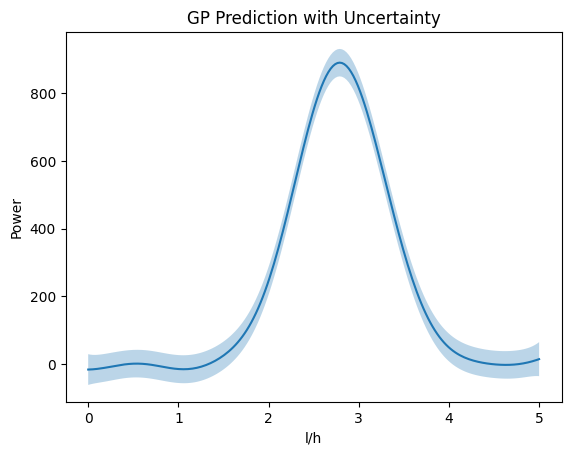

In [ ]:
l_vals = np.linspace(0, 5, 200)
d_fixed = np.full_like(l_vals, 0.05)

X_plot = np.column_stack((l_vals, d_fixed))

mean_pred, std_pred = gp.predict(X_plot, return_std=True)

plt.figure()
plt.plot(l_vals, mean_pred)

plt.fill_between(
    l_vals,
    mean_pred - 2*std_pred,
    mean_pred + 2*std_pred,
    alpha=0.3
)

plt.xlabel("l/h")
plt.ylabel("Power")
plt.title("GP Prediction with Uncertainty")
plt.show()

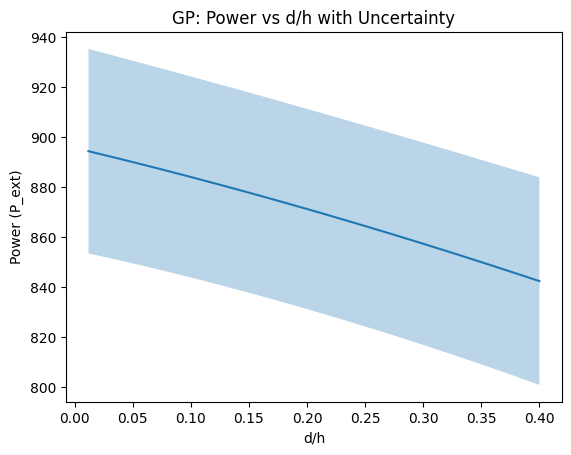

In [ ]:
d_vals = np.linspace(0.012, 0.4, 200)
l_fixed = np.full_like(d_vals, 2.8)
X_plot = np.column_stack((l_fixed, d_vals))
mean_pred, std_pred = gp.predict(X_plot, return_std=True)

plt.figure()

plt.plot(d_vals, mean_pred)

plt.fill_between(
    d_vals,
    mean_pred - 2 * std_pred,
    mean_pred + 2 * std_pred,
    alpha=0.3
)

plt.xlabel("d/h")
plt.ylabel("Power (P_ext)")
plt.title("GP: Power vs d/h with Uncertainty")

plt.show()